# Smart Energy Analytics

## Notebook 07: Feature Engineering & Final Model Optimization

### Objective

The objective of this notebook is to improve forecasting performance by creating additional informative features.

Instead of only relying on historical energy consumption, we will engineer new temporal and statistical features that help the LSTM model better understand consumption patterns.

The workflow includes:

- Load cleaned dataset
- Feature Engineering
- Feature Selection
- Normalize data
- Create sequences
- Train improved LSTM
- Evaluate performance
- Compare with previous models
- Save final production model

# Section 1: Import Libraries

In [4]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.models import load_model

from tensorflow.keras.layers import LSTM
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

# Section 2: Load Dataset

In [5]:
data = pd.read_csv("daily_energy_data.csv")

data.head()

,Datetime,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,2006-12-16,3.053475,0.088187,236.243763,13.082828,0.000000,1.378788,12.439394
1,2006-12-17,2.354486,0.156949,240.087028,9.999028,1.411806,2.907639,9.264583
2,2006-12-18,1.530435,0.112356,241.231694,6.421667,0.738194,1.820139,9.734722
3,2006-12-19,1.157079,0.104821,241.999313,4.926389,0.582639,5.279167,4.303472
4,2006-12-20,1.545658,0.111804,242.308063,6.467361,0.000000,1.838889,9.765972


# Section 3: Data Cleaning

In [6]:
# Remove missing values

data = data.dropna().reset_index(drop=True)

# Convert datetime column

data["Datetime"] = pd.to_datetime(data["Datetime"])

print(data.shape)

data.head()

(1433, 8)


,Datetime,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,2006-12-16,3.053475,0.088187,236.243763,13.082828,0.000000,1.378788,12.439394
1,2006-12-17,2.354486,0.156949,240.087028,9.999028,1.411806,2.907639,9.264583
2,2006-12-18,1.530435,0.112356,241.231694,6.421667,0.738194,1.820139,9.734722
3,2006-12-19,1.157079,0.104821,241.999313,4.926389,0.582639,5.279167,4.303472
4,2006-12-20,1.545658,0.111804,242.308063,6.467361,0.000000,1.838889,9.765972


# Section 4: Feature Engineering

In this section we create new features that may improve the forecasting performance.

The new features describe:

- Calendar information
- Historical consumption
- Weekly behavior
- Consumption trends

In [7]:
data["DayOfWeek"] = data["Datetime"].dt.dayofweek

In [8]:
data["Month"] = data["Datetime"].dt.month

In [9]:
data["Day"] = data["Datetime"].dt.day

In [10]:
data["Weekend"] = (
    data["DayOfWeek"] >= 5
).astype(int)

In [11]:
data["Lag_1"] = data["Global_active_power"].shift(1)

In [12]:
data["Lag_2"] = data["Global_active_power"].shift(2)

In [13]:
data["Lag_3"] = data["Global_active_power"].shift(3)

In [14]:
data["Lag_7"] = data["Global_active_power"].shift(7)

In [15]:
data = data.dropna().reset_index(drop=True)

In [16]:
print(data.head())

print()

print(data.shape)

    Datetime  Global_active_power  Global_reactive_power     Voltage  \
0 2006-12-23             3.314851               0.153799  240.136076   
1 2006-12-24             1.770842               0.104097  241.687437   
2 2006-12-25             1.904944               0.166861  243.399931   
3 2006-12-26             2.732021               0.114654  241.625438   
4 2006-12-27             1.061639               0.124237  243.767361   

   Global_intensity  Sub_metering_1  Sub_metering_2  Sub_metering_3  \
0         14.028056        1.853472        0.295139       10.226389   
1          7.640417        1.182639        3.529167        4.785417   
2          7.951528        4.597222        1.362500        4.024306   
3         11.347917        0.754167        1.759028       10.402083   
4          4.517500        0.000000        0.218056        4.844444   

   DayOfWeek  Month  Day  Weekend     Lag_1     Lag_2     Lag_3     Lag_7  
0          5     12   23        1  1.625929  1.193758  1.545658 

# Section 5: Advanced Feature Engineering

In this section, additional statistical and trend-based features are created.

These features help the model capture:

- Short-term trends
- Long-term trends
- Consumption variability
- Daily changes
- Growth rate

These engineered features provide richer information than using historical values alone.

### Rolling Mean (7 Days)

Represents the average energy consumption during the previous 7 days.
This helps the model understand short-term consumption trends.

In [17]:
data["RollingMean_7"] = (
    data["Global_active_power"]
    .rolling(window=7)
    .mean()
)

### Rolling Mean (30 Days)

Represents the monthly average energy consumption.
This captures long-term behavior.

In [18]:
data["RollingMean_30"] = (
    data["Global_active_power"]
    .rolling(window=30)
    .mean()
)

### Rolling Standard Deviation (7 Days)

Measures the variability of energy consumption during the previous week.
Higher values indicate unstable consumption.

In [19]:
data["RollingStd_7"] = (
    data["Global_active_power"]
    .rolling(window=7)
    .std()
)

### Rolling Standard Deviation (30 Days)

Measures long-term variability over the previous month.

In [20]:
data["RollingStd_30"] = (
    data["Global_active_power"]
    .rolling(window=30)
    .std()
)

### Daily Difference

Difference between today's and yesterday's energy consumption.
This helps detect increasing or decreasing trends.

In [21]:
data["DailyDifference"] = (
    data["Global_active_power"]
    .diff()
)

### Percentage Change

Represents the percentage increase or decrease compared to the previous day.

In [22]:
data["PercentChange"] = (
    data["Global_active_power"]
    .pct_change()
)

### Remove Missing Values

Rolling and lag operations generate missing values at the beginning of the dataset.

These rows are removed before model training.

In [23]:
data = data.dropna().reset_index(drop=True)

### Verify Engineered Features

In [24]:
print(data.shape)

print()

print(data.head())

(1397, 22)

    Datetime  Global_active_power  Global_reactive_power     Voltage  \
0 2007-01-21             2.366154               0.159539  238.968118   
1 2007-01-22             1.514232               0.117112  241.603132   
2 2007-01-23             1.234472               0.096028  242.762556   
3 2007-01-24             2.074899               0.123653  241.457694   
4 2007-01-25             1.108572               0.100111  243.424361   

   Global_intensity  Sub_metering_1  Sub_metering_2  Sub_metering_3  \
0         10.190694        7.184722        3.865972        8.054861   
1          6.355278        0.731944        2.071528        7.889583   
2          5.260833        0.000000        0.738889        3.514583   
3          8.733611        2.405556        1.722222        8.155556   
4          4.629306        0.804167        0.181944        7.804861   

   DayOfWeek  Month  ...     Lag_1     Lag_2     Lag_3     Lag_7  \
0          6      1  ...  2.176203  1.028083  1.264904  2.09

In [25]:
print(data.columns)

Index(['Datetime', 'Global_active_power', 'Global_reactive_power', 'Voltage',
       'Global_intensity', 'Sub_metering_1', 'Sub_metering_2',
       'Sub_metering_3', 'DayOfWeek', 'Month', 'Day', 'Weekend', 'Lag_1',
       'Lag_2', 'Lag_3', 'Lag_7', 'RollingMean_7', 'RollingMean_30',
       'RollingStd_7', 'RollingStd_30', 'DailyDifference', 'PercentChange'],
      dtype='object')


# Section 6: Feature Selection

In this section, we select the features that will be used to train the improved LSTM model.

The selected features include:

- Original energy measurements
- Calendar features
- Lag features
- Rolling statistics
- Trend features

Using only relevant features helps improve prediction accuracy while reducing unnecessary complexity.

In [26]:
selected_features = [

    # Original Features
    "Global_active_power",
    "Global_reactive_power",
    "Voltage",
    "Global_intensity",
    "Sub_metering_1",
    "Sub_metering_2",
    "Sub_metering_3",

    # Calendar Features
    "DayOfWeek",
    "Month",
    "Day",
    "Weekend",

    # Lag Features
    "Lag_1",
    "Lag_2",
    "Lag_3",
    "Lag_7",

    # Rolling Features
    "RollingMean_7",
    "RollingMean_30",
    "RollingStd_7",
    "RollingStd_30",

    # Trend Features
    "DailyDifference",
    "PercentChange"

]

In [27]:
model_data = data[selected_features]

model_data.head()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,DayOfWeek,Month,Day,...,Lag_1,Lag_2,Lag_3,Lag_7,RollingMean_7,RollingMean_30,RollingStd_7,RollingStd_30,DailyDifference,PercentChange
0,2.366154,0.159539,238.968118,10.190694,7.184722,3.865972,8.054861,6,1,21,...,2.176203,1.028083,1.264904,2.090213,1.639451,1.729837,0.530034,0.596798,0.189951,0.087286
1,1.514232,0.117112,241.603132,6.355278,0.731944,2.071528,7.889583,0,1,22,...,2.366154,2.176203,1.028083,1.492137,1.642607,1.669816,0.529075,0.517121,-0.851922,-0.360045
2,1.234472,0.096028,242.762556,5.260833,0.000000,0.738889,3.514583,1,1,23,...,1.514232,2.366154,2.176203,1.171114,1.651659,1.651937,0.520131,0.522750,-0.279760,-0.184754
3,2.074899,0.123653,241.457694,8.733611,2.405556,1.722222,8.155556,2,1,24,...,1.234472,1.514232,2.366154,1.977561,1.665564,1.657602,0.531474,0.526494,0.840426,0.680798
4,1.108572,0.100111,243.424361,4.629306,0.804167,0.181944,7.804861,3,1,25,...,2.074899,1.234472,1.514232,1.264904,1.643231,1.603487,0.553926,0.494727,-0.966326,-0.465722


In [28]:
print("Number of Features :", len(selected_features))

print()

print(model_data.shape)

Number of Features : 21

(1397, 21)


In [29]:
print(model_data.isnull().sum())

Global_active_power      0
Global_reactive_power    0
Voltage                  0
Global_intensity         0
Sub_metering_1           0
Sub_metering_2           0
Sub_metering_3           0
DayOfWeek                0
Month                    0
Day                      0
Weekend                  0
Lag_1                    0
Lag_2                    0
Lag_3                    0
Lag_7                    0
RollingMean_7            0
RollingMean_30           0
RollingStd_7             0
RollingStd_30            0
DailyDifference          0
PercentChange            0
dtype: int64


In [30]:
print(model_data.columns)

Index(['Global_active_power', 'Global_reactive_power', 'Voltage',
       'Global_intensity', 'Sub_metering_1', 'Sub_metering_2',
       'Sub_metering_3', 'DayOfWeek', 'Month', 'Day', 'Weekend', 'Lag_1',
       'Lag_2', 'Lag_3', 'Lag_7', 'RollingMean_7', 'RollingMean_30',
       'RollingStd_7', 'RollingStd_30', 'DailyDifference', 'PercentChange'],
      dtype='object')


In [31]:
model_data.describe().T

,count,mean,std,min,25%,50%,75%,max
Global_active_power,1397.0,1.075816,0.402080,0.173818,0.807842,1.068117,1.307022,2.798418
Global_reactive_power,1397.0,0.123493,0.034228,0.057811,0.098551,0.118847,0.140840,0.290162
Voltage,1397.0,240.835253,2.058566,231.088229,240.094778,240.965688,241.882903,247.435007
Global_intensity,1397.0,4.561216,1.661488,0.808333,3.483611,4.521528,5.482083,11.815972
Sub_metering_1,1397.0,1.122342,1.111234,0.000000,0.442361,0.773611,1.545833,7.767894
Sub_metering_2,1397.0,1.281746,1.449787,0.000000,0.300000,0.474306,1.878472,8.409028
Sub_metering_3,1397.0,6.419554,2.565435,0.000000,4.632639,6.430556,8.129861,16.488194
DayOfWeek,1397.0,2.993558,1.999452,0.000000,1.000000,3.000000,5.000000,6.000000
Month,1397.0,6.465999,3.352888,1.000000,4.000000,6.000000,9.000000,12.000000
Day,1397.0,15.729420,8.808278,1.000000,8.000000,16.000000,23.000000,31.000000


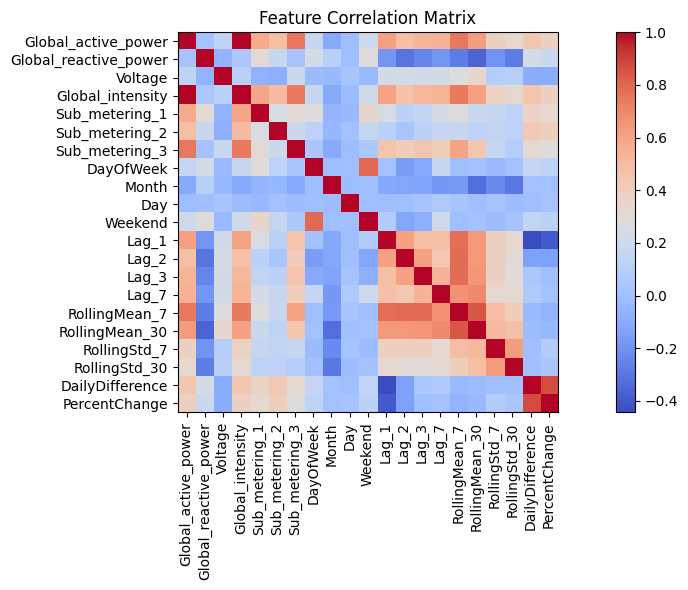

In [32]:
plt.figure(figsize=(12,6))

plt.imshow(model_data.corr(), cmap="coolwarm")

plt.colorbar()

plt.xticks(
    range(len(model_data.columns)),
    model_data.columns,
    rotation=90
)

plt.yticks(
    range(len(model_data.columns)),
    model_data.columns
)

plt.title("Feature Correlation Matrix")

plt.tight_layout()

plt.show()

# Section 7: Data Normalization

Before training the LSTM model, all selected features are normalized using MinMaxScaler.

Normalization scales all features into the range [0,1], allowing the neural network to train faster and more effectively.

The fitted scaler will also be saved because it is required later during deployment in the GUI application.

In [34]:
# ============================================
# Create Scaler
# ============================================

scaler = MinMaxScaler()

In [35]:
# ============================================
# Normalize Features
# ============================================

scaled_data = scaler.fit_transform(model_data)

In [36]:
scaled_df = pd.DataFrame(

    scaled_data,

    columns=model_data.columns

)

scaled_df.head()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,DayOfWeek,Month,Day,...,Lag_1,Lag_2,Lag_3,Lag_7,RollingMean_7,RollingMean_30,RollingStd_7,RollingStd_30,DailyDifference,PercentChange
0,0.835303,0.437819,0.482045,0.852350,0.924925,0.459741,0.488523,1.000000,0.0,0.666667,...,0.762929,0.325484,0.415715,0.730166,0.853151,1.000000,0.626819,0.741986,0.527784,0.166069
1,0.510712,0.255223,0.643240,0.503918,0.094227,0.246346,0.478499,0.000000,0.0,0.700000,...,0.835303,0.762929,0.325484,0.502293,0.854995,0.959414,0.625681,0.612876,0.188555,0.082533
2,0.404120,0.164478,0.714167,0.404492,0.000000,0.087869,0.213158,0.166667,0.0,0.733333,...,0.510712,0.835303,0.762929,0.379980,0.860282,0.947325,0.615069,0.621996,0.374848,0.115267
3,0.724332,0.283371,0.634343,0.719980,0.309679,0.204806,0.494630,0.333333,0.0,0.766667,...,0.404120,0.510712,0.835303,0.687245,0.868405,0.951155,0.628527,0.628063,0.739575,0.276902
4,0.356151,0.182052,0.754652,0.347120,0.103524,0.021637,0.473361,0.500000,0.0,0.800000,...,0.724332,0.404120,0.510712,0.415715,0.855359,0.914563,0.655168,0.576587,0.151305,0.062799


In [37]:
print(scaled_df.describe())

       Global_active_power  Global_reactive_power      Voltage  \
count          1397.000000            1397.000000  1397.000000   
mean              0.343671               0.282682     0.596266   
std               0.153197               0.147312     0.125931   
min               0.000000               0.000000     0.000000   
25%               0.241570               0.175339     0.550968   
50%               0.340737               0.262689     0.604245   
75%               0.431763               0.357343     0.660355   
max               1.000000               1.000000     1.000000   

       Global_intensity  Sub_metering_1  Sub_metering_2  Sub_metering_3  \
count       1397.000000     1397.000000     1397.000000     1397.000000   
mean           0.340934        0.144485        0.152425        0.389342   
std            0.150940        0.143055        0.172408        0.155592   
min            0.000000        0.000000        0.000000        0.000000   
25%            0.243038       

In [38]:
import joblib

joblib.dump(

    scaler,

    "energy_scaler.pkl"

)

['energy_scaler.pkl']

# Section 8: Create Sequences

The normalized dataset is transformed into sequential samples that can be used by the LSTM model.

Each input sample contains the previous 30 days of observations, while the target is the next day's Global Active Power.

Window Size = 30 days

In [39]:
# ============================================
# Define Window Size
# ============================================

WINDOW = 30

In [40]:
# ============================================
# Initialize Sequences
# ============================================

X = []

y = []

In [41]:
# ============================================
# Create Sequences
# ============================================

for i in range(WINDOW, len(scaled_data)):

    X.append(
        scaled_data[i-WINDOW:i]
    )

    y.append(
        scaled_data[i, 0]
    )

In [42]:
# ============================================
# Convert to NumPy Arrays
# ============================================

X = np.array(X)

y = np.array(y)

In [43]:
# ============================================
# Verify Shapes
# ============================================

print("X Shape :", X.shape)

print("y Shape :", y.shape)

X Shape : (1367, 30, 21)
y Shape : (1367,)


In [44]:
# ============================================
# Inspect First Sample
# ============================================

print(X[0])

print()

print(y[0])

[[0.83530295 0.43781868 0.48204539 0.85235001 0.92492532 0.45974069
  0.48852293 1.         0.         0.66666667 1.         0.76292948
  0.32548399 0.4157152  0.73016635 0.85315097 1.         0.62681868
  0.74198622 0.52778393 0.16606852]
 [0.51071169 0.25522287 0.64324009 0.50391773 0.09422688 0.24634569
  0.47849893 0.         0.         0.7        0.         0.83530295
  0.76292948 0.32548399 0.50229347 0.85499474 0.95941434 0.62568134
  0.61287622 0.18855494 0.08253304]
 [0.40412031 0.16447789 0.71416683 0.40449183 0.         0.08786853
  0.21315756 0.16666667 0.         0.73333333 0.         0.51071169
  0.83530295 0.76292948 0.37998012 0.86028197 0.94732467 0.61506887
  0.62199642 0.37484827 0.11526734]
 [0.72433154 0.28337109 0.63434307 0.71997981 0.30967923 0.20480634
  0.49463    0.33333333 0.         0.76666667 0.         0.40412031
  0.51071169 0.83530295 0.68724493 0.86840474 0.95115541 0.62852696
  0.62806316 0.73957543 0.27690226]
 [0.3561511  0.18205185 0.75465221 0.347

In [45]:
print(f"Window Size     : {WINDOW}")

print(f"Number of Features : {X.shape[2]}")

print(f"Total Samples      : {X.shape[0]}")

Window Size     : 30
Number of Features : 21
Total Samples      : 1367


# Section 9: Train-Test Split

The dataset is divided into training and testing sets.

Since this is a time-series forecasting task, the chronological order is preserved.

- 80% Training
- 20% Testing

No random shuffling is applied.

In [46]:
# ============================================
# Train-Test Split
# ============================================

split = int(len(X) * 0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

In [47]:
print("Training Samples :", X_train.shape)

print("Testing Samples  :", X_test.shape)

print()

print("Training Labels :", y_train.shape)

print("Testing Labels  :", y_test.shape)

Training Samples : (1093, 30, 21)
Testing Samples  : (274, 30, 21)

Training Labels : (1093,)
Testing Labels  : (274,)


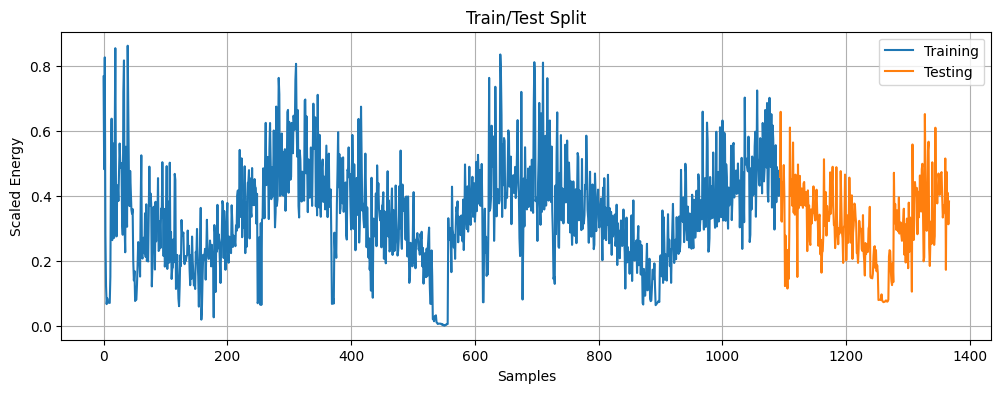

In [48]:
plt.figure(figsize=(12,4))

plt.plot(y_train, label="Training")

plt.plot(
    range(len(y_train), len(y_train)+len(y_test)),
    y_test,
    label="Testing"
)

plt.title("Train/Test Split")

plt.xlabel("Samples")

plt.ylabel("Scaled Energy")

plt.legend()

plt.grid(True)

plt.show()

# Section 10: Build Final LSTM Model

This section defines the final production-ready LSTM architecture.

The model consists of:

- Two stacked LSTM layers
- Dropout regularization
- Dense hidden layer
- Output layer

The model is optimized using the Adam optimizer and Mean Squared Error loss.

In [49]:
def build_model(input_shape):

    model = Sequential()

    # First LSTM Layer
    model.add(

        LSTM(

            128,

            return_sequences=True,

            input_shape=input_shape

        )

    )

    model.add(

        Dropout(0.3)

    )

    # Second LSTM Layer
    model.add(

        LSTM(

            64

        )

    )

    model.add(

        Dropout(0.3)

    )

    # Dense Layer
    model.add(

        Dense(

            32,

            activation="relu"

        )

    )

    # Output Layer
    model.add(

        Dense(1)

    )

    model.compile(

        optimizer="adam",

        loss="mse",

        metrics=["mae"]

    )

    return model

In [50]:
model = build_model(

    (X_train.shape[1], X_train.shape[2])

)

c:\Users\abdul\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [51]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 128)        │        76,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 128,321 (501.25 KB)

 Trainable params: 128,321 (501.25 KB)

 Non-trainable params: 0 (0.00 B)

In [52]:
from tensorflow.keras.utils import plot_model

plot_model(

    model,

    show_shapes=True,

    show_layer_names=True,

    dpi=100

)

You must install pydot (`pip install pydot`) for `plot_model` to work.


# Section 11: Train Final Model

The final LSTM model is trained using several callbacks to improve convergence and prevent overfitting.

Training techniques:

- EarlyStopping
- ReduceLROnPlateau
- ModelCheckpoint

In [53]:
# ============================================
# Training Callbacks
# ============================================

early_stop = EarlyStopping(

    monitor="val_loss",

    patience=10,

    restore_best_weights=True

)

reduce_lr = ReduceLROnPlateau(

    monitor="val_loss",

    factor=0.5,

    patience=5,

    min_lr=1e-6,

    verbose=1

)

checkpoint = ModelCheckpoint(

    "final_energy_model.keras",

    monitor="val_loss",

    save_best_only=True,

    verbose=1

)

In [54]:
history = model.fit(

    X_train,

    y_train,

    validation_data=(X_test, y_test),

    epochs=50,

    batch_size=32,

    callbacks=[

        early_stop,

        reduce_lr,

        checkpoint

    ],

    verbose=1

)

Epoch 1/50
32/35 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0638 - mae: 0.1910
Epoch 1: val_loss improved from None to 0.00938, saving model to final_energy_model.keras
35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - loss: 0.0356 - mae: 0.1427 - val_loss: 0.0094 - val_mae: 0.0745 - learning_rate: 0.0010
Epoch 2/50
33/35 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0193 - mae: 0.1045
Epoch 2: val_loss improved from 0.00938 to 0.00907, saving model to final_energy_model.keras
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0186 - mae: 0.1023 - val_loss: 0.0091 - val_mae: 0.0729 - learning_rate: 0.0010
Epoch 3/50
31/35 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0177 - mae: 0.1012
Epoch 3: val_loss improved from 0.00907 to 0.00879, saving model to final_energy_model.keras
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0168 - mae: 0.0980 - val_loss: 0.0088 - val_mae: 0.0709 - learning_rate: 0.0010
Epoch 4/50
34/35 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0157 - mae: 0.0946
Epoch 4: val_l

In [55]:
best_model = load_model(
    "final_energy_model.keras"
)

# Section 12: Final Evaluation

The final model is evaluated using multiple regression metrics.

Performance is compared against previous notebooks to verify whether feature engineering improves forecasting accuracy.

In [57]:
predictions = best_model.predict(X_test)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


In [58]:
mae = mean_absolute_error(

    y_test,

    predictions

)

rmse = np.sqrt(

    mean_squared_error(

        y_test,

        predictions

    )

)

r2 = r2_score(

    y_test,

    predictions

)

print(f"MAE  : {mae:.4f}")

print(f"RMSE : {rmse:.4f}")

print(f"R²   : {r2:.4f}")

MAE  : 0.0679
RMSE : 0.0909
R²   : 0.4003


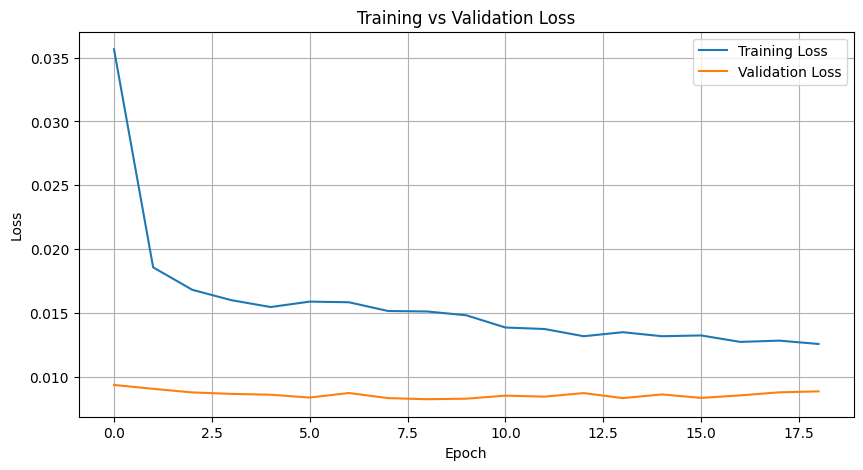

In [59]:
plt.figure(figsize=(10,5))

plt.plot(

    history.history["loss"],

    label="Training Loss"

)

plt.plot(

    history.history["val_loss"],

    label="Validation Loss"

)

plt.title("Training vs Validation Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.grid(True)

plt.show()

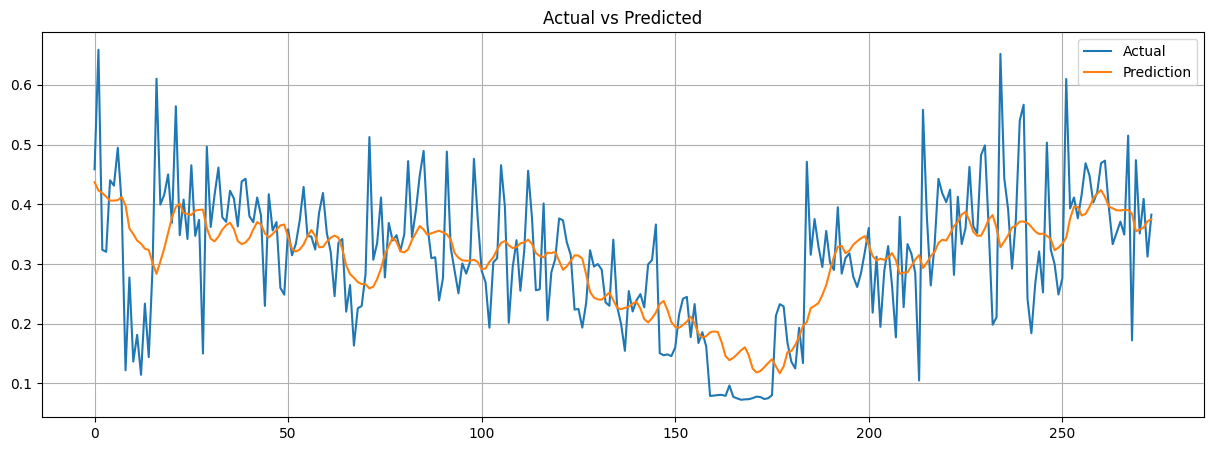

In [60]:
plt.figure(figsize=(15,5))

plt.plot(

    y_test,

    label="Actual"

)

plt.plot(

    predictions,

    label="Prediction"

)

plt.title("Actual vs Predicted")

plt.legend()

plt.grid(True)

plt.show()

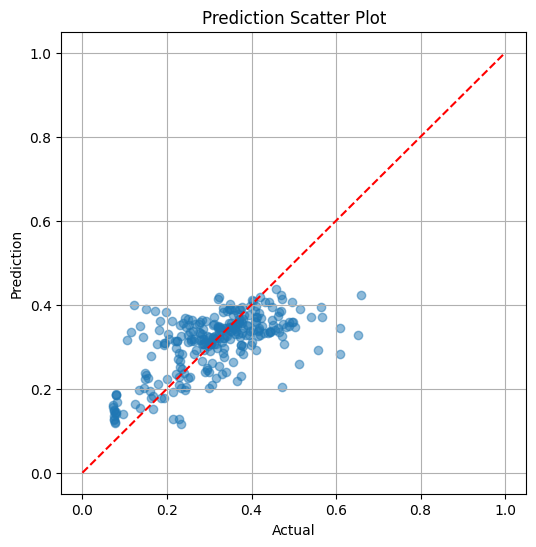

In [61]:
plt.figure(figsize=(6,6))

plt.scatter(

    y_test,

    predictions,

    alpha=0.5

)

plt.plot(

    [0,1],

    [0,1],

    "r--"

)

plt.xlabel("Actual")

plt.ylabel("Prediction")

plt.title("Prediction Scatter Plot")

plt.grid(True)

plt.show()

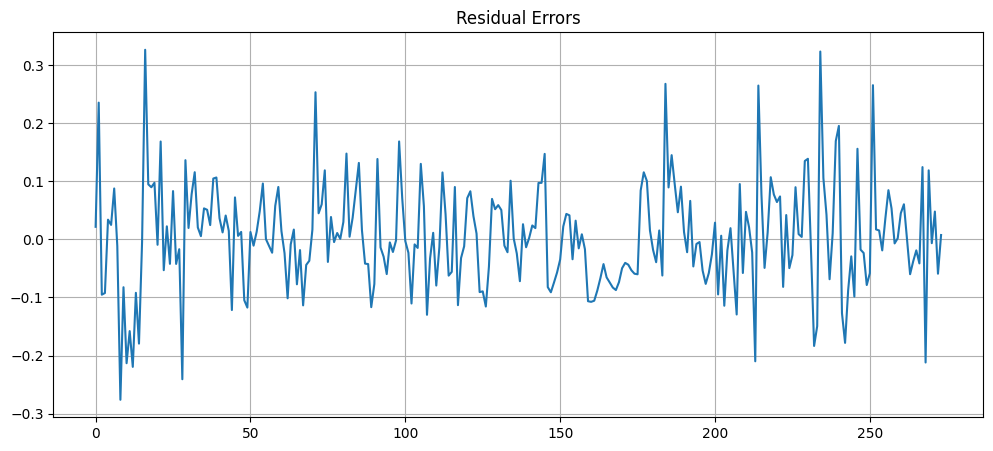

In [62]:
residuals = y_test - predictions.flatten()

plt.figure(figsize=(12,5))

plt.plot(residuals)

plt.title("Residual Errors")

plt.grid(True)

plt.show()

In [63]:
comparison = pd.DataFrame({

    "Model":[

        "Baseline LSTM",

        "Advanced LSTM",

        "Feature Engineered LSTM"

    ],

    "MAE":[

        0.0560,

        0.0553,

        mae

    ],

    "RMSE":[

        0.0750,

        0.0749,

        rmse

    ],

    "R2":[

        0.410,

        0.425,

        r2

    ]

})

comparison

,Model,MAE,RMSE,R2
0,Baseline LSTM,0.056000,0.075000,0.410000
1,Advanced LSTM,0.055300,0.074900,0.425000
2,Feature Engineered LSTM,0.067904,0.090892,0.400256


# Section 13: Save Final Production Model

The final trained model and preprocessing scaler are saved for deployment.

These files will later be loaded by the Smart Energy Dashboard.

In [64]:
best_model.save(

    "final_energy_model.keras"

)

In [65]:
import joblib

joblib.dump(

    scaler,

    "energy_scaler.pkl"

)

['energy_scaler.pkl']

In [66]:
import os

print(

    "Model Exists:",

    os.path.exists("final_energy_model.keras")

)

print(

    "Scaler Exists:",

    os.path.exists("energy_scaler.pkl")

)

Model Exists: True
Scaler Exists: True
